# Assembly101 Exploration — Track 7 / Domain Adaptation Exo→Ego

This notebook performs the initial data exploration on the Assembly101
fine-grained annotations, used in this project for the **24-verb classification
task** under exocentric→egocentric domain adaptation.

**Decisions documented in this notebook:**
- Source view: `C10095_rgb` (fixed RGB, exocentric, "v1" in the dataset notation)
- Target view: `HMC_21176875_mono10bit` (head-mounted monochrome, egocentric, "e1")
- Classification target: `verb_id` (24 classes)
- Split: official Assembly101 train/val/test (per-sequence, not per-subject)

Outputs (figures saved to `figures/`):
- 1. Class distribution (long-tail)
- 2. Source vs target sample counts
- 3. Segment length distribution
- 4. Class coverage and balance per domain

In [1]:
"""Setup imports, paths, and visual style."""

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# repo-root-relative imports
PROJECT_ROOT = Path.cwd().parent  # if running this notebook from notebooks/
ANN_DIR = PROJECT_ROOT / "data" / "raw" / "assembly101-annotations" / "fine-grained-annotations"
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_VIEW = "C10095_rgb"
TARGET_VIEW = "HMC_21176875_mono10bit"

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110

print("Annotations dir:", ANN_DIR)
print("Figures dir:    ", FIG_DIR)
print("Source view:    ", SOURCE_VIEW)
print("Target view:    ", TARGET_VIEW)

Annotations dir: c:\Users\massi\Documents\GitHub\dl26-projects\data\raw\assembly101-annotations\fine-grained-annotations
Figures dir:     c:\Users\massi\Documents\GitHub\dl26-projects\figures
Source view:     C10095_rgb
Target view:     HMC_21176875_mono10bit


In [2]:
"""Load CSVs and add sequence_id, view, subject columns."""

def load_split(name: str) -> pd.DataFrame:
    df = pd.read_csv(ANN_DIR / f"{name}.csv")
    parts = df["video"].str.split("/", n=1, expand=True)
    df["sequence_id"] = parts[0]
    df["view"] = parts[1].str.replace(".mp4", "", regex=False)
    df["domain"] = np.where(df["view"] == SOURCE_VIEW, "source",
                    np.where(df["view"] == TARGET_VIEW, "target", "other"))
    df["segment_length"] = df["end_frame"] - df["start_frame"]
    df["split"] = name
    return df

train = load_split("train")
val = load_split("validation")
test = load_split("test")

# A unified view filtered to only our 2 chosen views
all_df = pd.concat([train, val, test], ignore_index=True)
focus = all_df[all_df["domain"].isin(["source", "target"])].copy()

print("Loaded:")
for split, df in [("train", train), ("validation", val), ("test", test)]:
    print(f"  {split}: total={len(df):,}, source={(df['domain']=='source').sum():,}, target={(df['domain']=='target').sum():,}")
print(f"Focus rows (source+target only): {len(focus):,}")

Loaded:
  train: total=566,855, source=47,649, target=24,743
  validation: total=186,788, source=15,696, target=9,416
  test: total=259,880, source=21,934, target=11,307
Focus rows (source+target only): 130,745


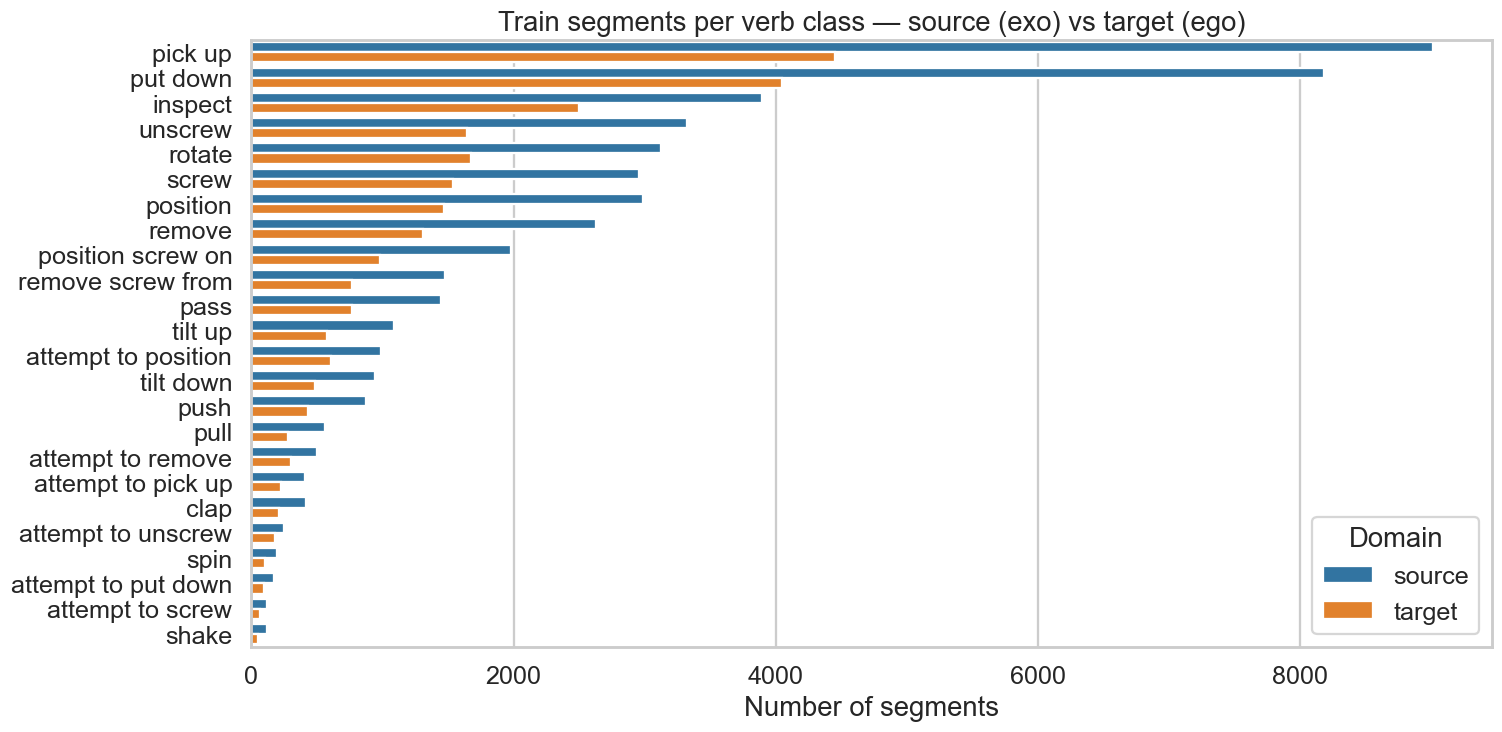


Top 5 verbs by source frequency:
verb_cls
pick up     9009
put down    8184
inspect     3898
unscrew     3321
rotate      3127
Name: count, dtype: int64

Top 5 verbs by target frequency:
verb_cls
pick up     4452
put down    4043
inspect     2499
rotate      1672
unscrew     1644
Name: count, dtype: int64


In [3]:
"""Figure 1 — Class distribution per domain on the focus dataset."""

fig, ax = plt.subplots(figsize=(14, 7))

# Use train split only for the class distribution we will train on
train_focus = focus[focus["split"] == "train"]
counts = (
    train_focus
    .groupby(["verb_cls", "domain"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

# Order verbs by total count (long-tail-friendly)
verb_order = (
    train_focus.groupby("verb_cls").size().sort_values(ascending=False).index.tolist()
)

sns.barplot(
    data=counts,
    y="verb_cls",
    x="count",
    hue="domain",
    order=verb_order,
    palette={"source": "#1f77b4", "target": "#ff7f0e"},
    ax=ax,
)
ax.set_title("Train segments per verb class — source (exo) vs target (ego)")
ax.set_xlabel("Number of segments")
ax.set_ylabel("")
ax.legend(title="Domain", loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_class_distribution_train.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 verbs by source frequency:")
print(train_focus[train_focus["domain"] == "source"]["verb_cls"].value_counts().head())
print("\nTop 5 verbs by target frequency:")
print(train_focus[train_focus["domain"] == "target"]["verb_cls"].value_counts().head())

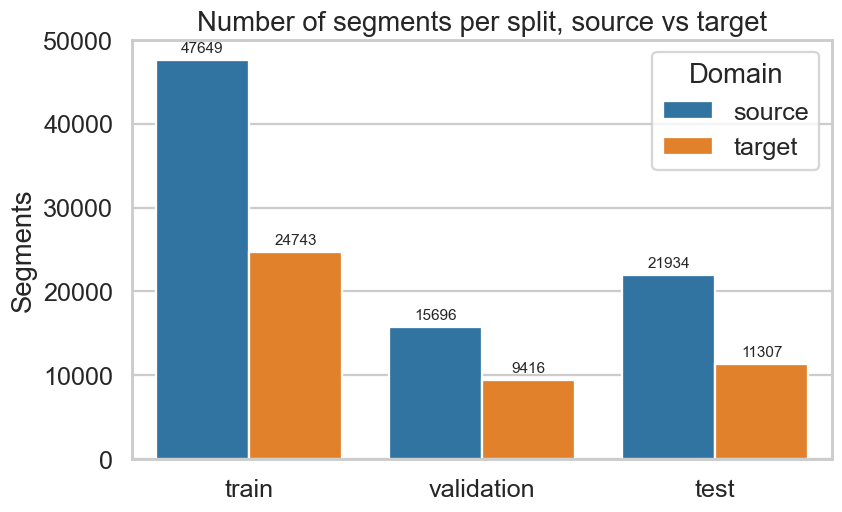

In [4]:
"""Figure 2 — Total samples per split and domain."""

fig, ax = plt.subplots(figsize=(8, 5))

vol = (
    focus.groupby(["split", "domain"])
    .size()
    .reset_index(name="count")
)

sns.barplot(
    data=vol,
    x="split",
    y="count",
    hue="domain",
    order=["train", "validation", "test"],
    palette={"source": "#1f77b4", "target": "#ff7f0e"},
    ax=ax,
)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, fontsize=10)

ax.set_title("Number of segments per split, source vs target")
ax.set_xlabel("")
ax.set_ylabel("Segments")
ax.legend(title="Domain")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_split_volume.png", dpi=150, bbox_inches="tight")
plt.show()

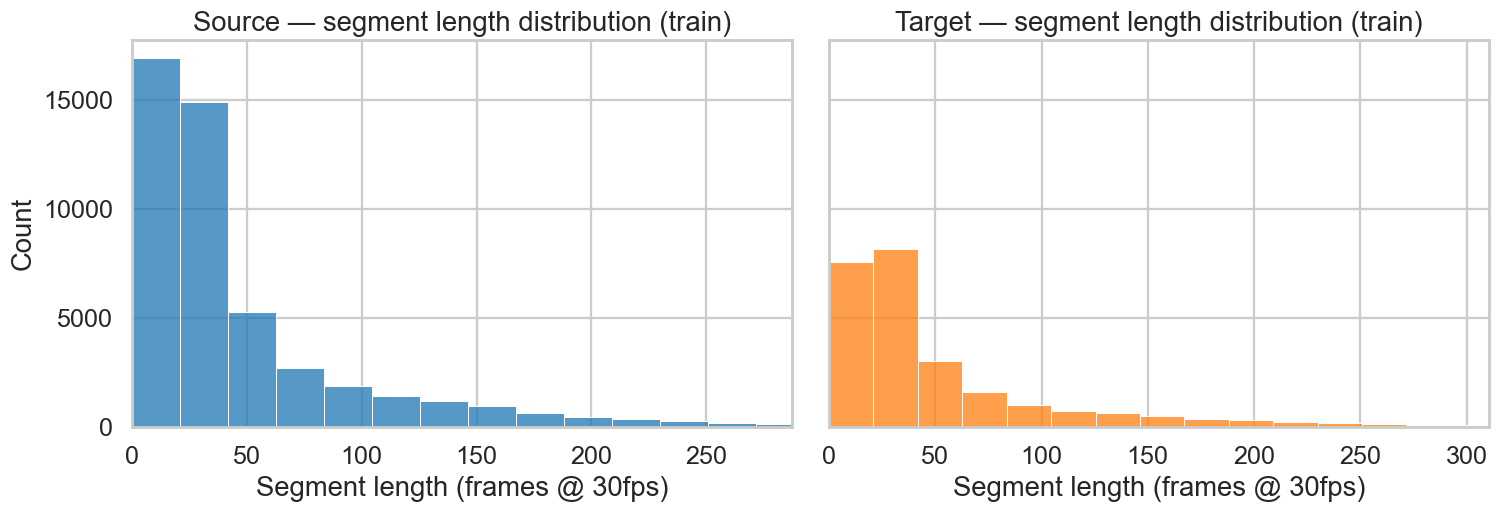

Source train: median=28, mean=49.9, p95=171
Target train: median=30, mean=54.5, p95=187


In [5]:
"""Figure 3 — Distribution of segment lengths in frames."""

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, dom in zip(axes, ["source", "target"]):
    data = focus[(focus["split"] == "train") & (focus["domain"] == dom)]["segment_length"]
    sns.histplot(data, bins=50, color="#1f77b4" if dom == "source" else "#ff7f0e", ax=ax)
    ax.set_title(f"{dom.capitalize()} — segment length distribution (train)")
    ax.set_xlabel("Segment length (frames @ 30fps)")
    ax.set_ylabel("Count")
    ax.set_xlim(0, data.quantile(0.99))  # clip the very-long tail to read the bulk

plt.tight_layout()
plt.savefig(FIG_DIR / "03_segment_length.png", dpi=150, bbox_inches="tight")
plt.show()

print("Source train: median={:.0f}, mean={:.1f}, p95={:.0f}".format(
    focus[(focus["split"]=="train") & (focus["domain"]=="source")]["segment_length"].median(),
    focus[(focus["split"]=="train") & (focus["domain"]=="source")]["segment_length"].mean(),
    focus[(focus["split"]=="train") & (focus["domain"]=="source")]["segment_length"].quantile(0.95),
))
print("Target train: median={:.0f}, mean={:.1f}, p95={:.0f}".format(
    focus[(focus["split"]=="train") & (focus["domain"]=="target")]["segment_length"].median(),
    focus[(focus["split"]=="train") & (focus["domain"]=="target")]["segment_length"].mean(),
    focus[(focus["split"]=="train") & (focus["domain"]=="target")]["segment_length"].quantile(0.95),
))

Verbs MORE common in target than in source (top 5):
domain                 source    target  delta_target_vs_source
verb_cls                                                       
inspect              0.081807  0.100998                0.019192
attempt to position  0.020714  0.024411                0.003697
attempt to unscrew   0.005226  0.007234                0.002009
rotate               0.065626  0.067575                0.001949
attempt to remove    0.010430  0.012246                0.001815

Verbs MORE common in source than in target (top 5):
domain      source    target  delta_target_vs_source
verb_cls                                            
remove    0.055216  0.052823               -0.002393
unscrew   0.069697  0.066443               -0.003254
position  0.062751  0.059451               -0.003299
put down  0.171756  0.163400               -0.008356
pick up   0.189070  0.179930               -0.009140


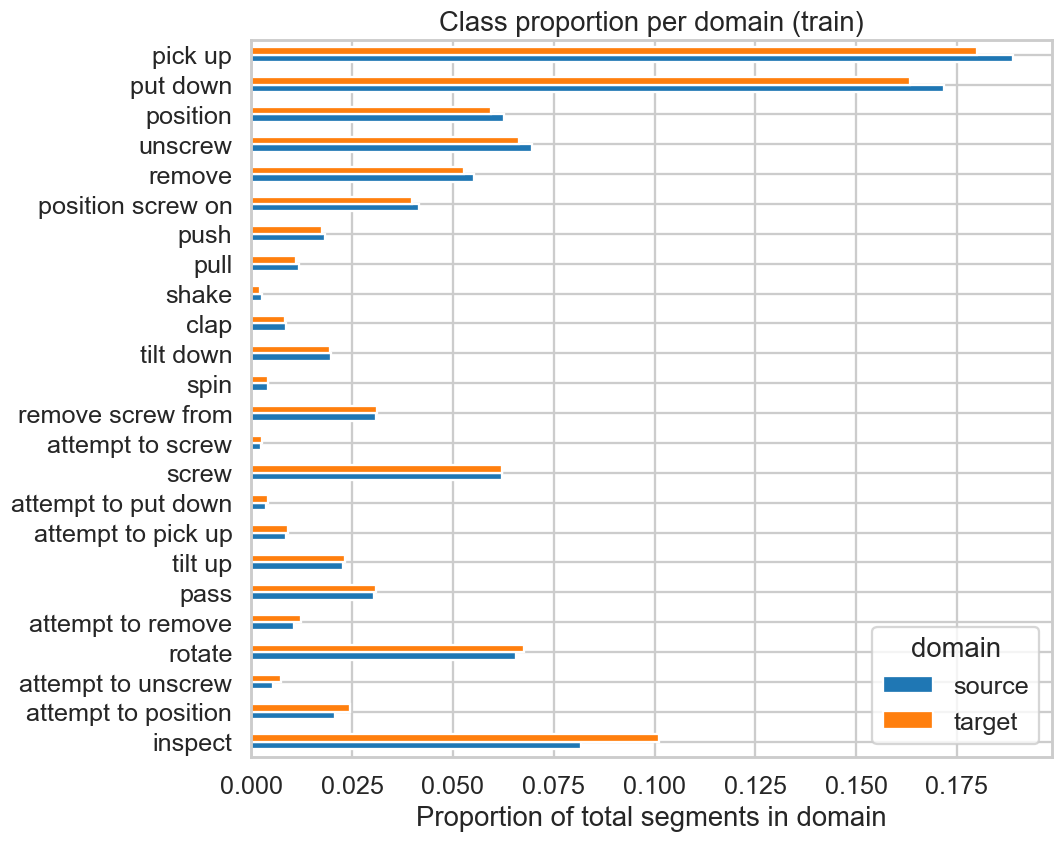

In [6]:
"""Figure 4 — Class balance (proportion) per domain.

Useful to see if some classes are over/under-represented in source vs target.
"""

train_focus = focus[focus["split"] == "train"]

prop = (
    train_focus
    .groupby(["domain", "verb_cls"])
    .size()
    .reset_index(name="count")
)
prop["proportion"] = prop.groupby("domain")["count"].transform(lambda x: x / x.sum())

# Pivot so we can easily see source vs target side by side
pivot = prop.pivot(index="verb_cls", columns="domain", values="proportion").fillna(0)
pivot["delta_target_vs_source"] = pivot["target"] - pivot["source"]
pivot = pivot.sort_values("delta_target_vs_source", ascending=False)

print("Verbs MORE common in target than in source (top 5):")
print(pivot.head())
print("\nVerbs MORE common in source than in target (top 5):")
print(pivot.tail())

fig, ax = plt.subplots(figsize=(10, 8))
pivot[["source", "target"]].plot(kind="barh", ax=ax,
    color=["#1f77b4", "#ff7f0e"])
ax.set_title("Class proportion per domain (train)")
ax.set_xlabel("Proportion of total segments in domain")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusions — to be referenced in the report

1. **Volume**: ~47.6k labelled source + ~24.7k unlabelled target segments in the train split — a healthy size for DA training on pre-extracted features.
2. **Class coverage**: all 24 verbs are present in both domains, so no class needs to be filtered out at this stage.
3. **Long-tail**: the top 2 verbs (`pick up`, `put down`) account for ~36% of the train set. Balanced accuracy and macro-F1 will be reported alongside top-1.
4. **Sequences**: every target sequence has its source counterpart (102 out of 102), but ~109 source sequences have no ego recording. We keep them all (the DA framework samples source and target independently).
5. **Splits**: official Assembly101 train/val/test are per-sequence (subjects overlap across splits). We respect the official splits to align with published results.